In [105]:
import feedparser
import pandas as pd
import time
import requests
import os

In [106]:

# Configuration
nom_fichier = "bulletins_anssi_avec_cves.csv"
url_avis = "https://www.cert.ssi.gouv.fr/avis/feed/"
url_alertes = "https://www.cert.ssi.gouv.fr/alerte/feed/"


def extraire_flux_rss(url, type_bulletin):
    flux = feedparser.parse(url)
    liste_bulletins = []
    for entry in flux.entries:
        liste_bulletins.append({
            "id_anssi": entry.link.strip("/").split("/")[-1],
            "titre": entry.title,
            "description": entry.description,
            "date_publication": entry.published,
            "lien": entry.link,
            "type_bulletin": type_bulletin
        })
    time.sleep(1)
    return liste_bulletins


In [107]:
def extraire_cves_du_bulletin(lien_bulletin):
    url_json = f"{lien_bulletin.strip('/')}/json/"
    try:
        response = requests.get(url_json)
        if response.status_code == 200:
            data = response.json()
            return [item['name'] for item in data.get("cves", [])]
        return []
    except Exception as e:
        print(f"Erreur pour {lien_bulletin}: {e}")
        return []

In [108]:
def mettre_a_jour_donnees(nom_fichier, url_avis, url_alertes):
    print("Récupération des flux...")
    avis = extraire_flux_rss(url_avis, "Avis")
    alertes = extraire_flux_rss(url_alertes, "Alerte")
    df_flux_actuel = pd.DataFrame(avis + alertes)
    df_flux_actuel['id_anssi'] = df_flux_actuel['id_anssi'].astype(str).str.strip()

    if os.path.exists(nom_fichier):
        df_existant = pd.read_csv(nom_fichier)
        df_existant['id_anssi'] = df_existant['id_anssi'].astype(str).str.strip()
        
        # On cherche ce qui est dans le flux mais PAS dans le CSV
        mask = ~df_flux_actuel['id_anssi'].isin(df_existant['id_anssi'])
        nouveaux_items = df_flux_actuel[mask].copy()
        
        if not nouveaux_items.empty:
            print(f"{len(nouveaux_items)} manquants détectés. Extraction des CVE...")
            nouveaux_items['liste_cves'] = nouveaux_items['lien'].apply(extraire_cves_du_bulletin)
            df_final = pd.concat([df_existant, nouveaux_items], ignore_index=True)
            df_final = df_final.drop_duplicates(subset=['id_anssi'])
            df_final.to_csv(nom_fichier, index=False, encoding="utf-8-sig")
            print(f"Mise à jour réussie. Total : {len(df_final)}")
        else:
            print("Aucun nouveau bulletin à ajouter.")
            df_final = df_existant
    else:
        print("Fichier inexistant, création complète du CSV...")
        df_flux_actuel['liste_cves'] = df_flux_actuel['lien'].apply(extraire_cves_du_bulletin)
        df_final = df_flux_actuel.drop_duplicates(subset=['id_anssi'])
        df_final.to_csv(nom_fichier, index=False, encoding="utf-8-sig")

    print(f"Nombre total de bulletins dans le CSV : {len(df_final)}")
    display(df_final.tail())
    return df_final

In [109]:
df_final = mettre_a_jour_donnees(nom_fichier, url_avis, url_alertes)

Récupération des flux...
Aucun nouveau bulletin à ajouter.
Nombre total de bulletins dans le CSV : 80


,id_anssi,titre,description,date_publication,lien,type_bulletin,liste_cves
75,CERTFR-2026-ALE-001,[MàJ] Multiples vulnérabilités dans Ivanti End...,[Mise à jour du 09 février 2026] Le 6 février ...,"Fri, 30 Jan 2026 00:00:00 +0000",https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,Alerte,"['CVE-2026-1340', 'CVE-2026-1281']"
76,CERTFR-2026-ALE-002,[MàJ] Vulnérabilité dans Cisco Catalyst SD-WAN...,Une vulnérabilité a été découverte dans Cisco ...,"Wed, 25 Feb 2026 00:00:00 +0000",https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,Alerte,"['CVE-2026-20127', 'CVE-2022-20775']"
77,CERTFR-2026-ALE-003,Note d’alerte – Ciblage des messageries instan...,Les travaux conjoints des services membres du ...,"Fri, 20 Mar 2026 00:00:00 +0000",https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,Alerte,[]
78,CERTFR-2026-ALE-004,Vulnérabilité dans F5 BIG-IP Access Policy Man...,"Le 15 octobre 2025, F5 a publié un avis de séc...","Tue, 31 Mar 2026 00:00:00 +0000",https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,Alerte,['CVE-2025-53521']
79,CERTFR-2026-ALE-005,[Màj] Vulnérabilité dans Microsoft Exchange Se...,"[Mise à jour du 11 juin 2026] Le 9 juin 2026, ...","Fri, 15 May 2026 00:00:00 +0000",https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,Alerte,['CVE-2026-42897']


In [110]:

print("Aperçu :")
display(df_final.head())


Aperçu :


,id_anssi,titre,description,date_publication,lien,type_bulletin,liste_cves
0,CERTFR-2026-AVI-0699,Vulnérabilité dans Cisco Catalyst SD-WAN (05 j...,Une vulnérabilité a été découverte dans Cisco ...,"Fri, 05 Jun 2026 00:00:00 +0000",https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...,Avis,['CVE-2026-20245']
1,CERTFR-2026-AVI-0715,Multiples vulnérabilités dans les produits SAP...,De multiples vulnérabilités ont été découverte...,"Tue, 09 Jun 2026 00:00:00 +0000",https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...,Avis,"['CVE-2026-29145', 'CVE-2026-44751', 'CVE-2026..."
2,CERTFR-2026-AVI-0717,Multiples vulnérabilités dans OpenSSL (10 juin...,De multiples vulnérabilités ont été découverte...,"Wed, 10 Jun 2026 00:00:00 +0000",https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...,Avis,"['CVE-2026-34181', 'CVE-2026-42766', 'CVE-2026..."
3,CERTFR-2026-AVI-0718,Vulnérabilité dans PostgreSQL (10 juin 2026),Une vulnérabilité a été découverte dans Postgr...,"Wed, 10 Jun 2026 00:00:00 +0000",https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...,Avis,['CVE-2026-9617']
4,CERTFR-2026-AVI-0719,Multiples vulnérabilités dans les produits Spr...,De multiples vulnérabilités ont été découverte...,"Wed, 10 Jun 2026 00:00:00 +0000",https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...,Avis,"['CVE-2026-41697', 'CVE-2026-41003', 'CVE-2026..."


In [111]:
# Test pour vérifier le update

# 1. On supprime les 5 dernières lignes pour simuler un fichier incomplet
if os.path.exists(nom_fichier):
    df_test = pd.read_csv(nom_fichier)
    taille_avant = len(df_test)
    df_test = df_test.iloc[:-5] 
    df_test.to_csv(nom_fichier, index=False, encoding="utf-8-sig")
    print(f"Test : {taille_avant} -> {len(df_test)} lignes. (Les 5 dernières supprimées)")
    display(df_test.tail(7))
    
    # 2. On lance la mise à jour pour réparer le fichier
    print("\n Lancement de la mise à jour (Réparation)")
    df_final = mettre_a_jour_donnees(nom_fichier, url_avis, url_alertes)
    
    # 3. Vérification finale
    print("\n Vérification finale des données")
    print(f"Taille finale après update : {len(df_final)} lignes.")
    print("Voici les dernières lignes (les 5 que nous avions supprimées doivent être revenues) :")
    display(df_final.tail(7))
else:
    print("Fichier introuvable, impossible de réaliser le test.")

Test : 80 -> 75 lignes. (Les 5 dernières supprimées)


,id_anssi,titre,description,date_publication,lien,type_bulletin,liste_cves
68,CERTFR-2025-ALE-008,[MàJ] Vulnérabilité dans Roundcube (05 juin 2025),[Mise à jour du 06 juin 2025] Une preuve de co...,"Thu, 05 Jun 2025 00:00:00 +0000",https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,Alerte,['CVE-2025-49113']
69,CERTFR-2025-ALE-009,Multiples vulnérabilités dans Citrix NetScaler...,**[Mise à jour du 17 juillet 2025]** L'éditeur...,"Tue, 01 Jul 2025 00:00:00 +0000",https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,Alerte,"['CVE-2025-6543', 'CVE-2025-5777']"
70,CERTFR-2025-ALE-010,[MàJ] Multiples vulnérabilités dans Microsoft ...,**[Mise à jour du 23 juillet 2025]** Le 20 jui...,"Mon, 21 Jul 2025 00:00:00 +0000",https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,Alerte,"['CVE-2025-53771', 'CVE-2025-53770']"
71,CERTFR-2025-ALE-011,Incidents de sécurité dans les pare-feux Sonic...,"[Mise à jour du 7 août 2025] Le 6 août 2025, S...","Tue, 05 Aug 2025 00:00:00 +0000",https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,Alerte,['CVE-2024-40766']
72,CERTFR-2025-ALE-012,Vulnérabilité dans Citrix NetScaler ADC et Net...,"Le 26 août 2025, Citrix a publié un bulletin d...","Tue, 26 Aug 2025 00:00:00 +0000",https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,Alerte,['CVE-2025-7775']
73,CERTFR-2025-ALE-013,[MàJ] Multiples vulnérabilités dans Cisco ASA ...,**[Mise à jour du 07 novembre 2025]** Le 5 nov...,"Thu, 25 Sep 2025 00:00:00 +0000",https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,Alerte,"['CVE-2025-20362', 'CVE-2025-20333']"
74,CERTFR-2025-ALE-014,[MàJ] Vulnérabilité dans React Server Componen...,**[Mise à jour du 11 décembre 2025]** Le CERT-...,"Fri, 05 Dec 2025 00:00:00 +0000",https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,Alerte,"['CVE-2025-55182', 'CVE-2025-66478']"



 Lancement de la mise à jour (Réparation)
Récupération des flux...
5 manquants détectés. Extraction des CVE...
Mise à jour réussie. Total : 80
Nombre total de bulletins dans le CSV : 80


,id_anssi,titre,description,date_publication,lien,type_bulletin,liste_cves
75,CERTFR-2026-ALE-001,[MàJ] Multiples vulnérabilités dans Ivanti End...,[Mise à jour du 09 février 2026] Le 6 février ...,"Fri, 30 Jan 2026 00:00:00 +0000",https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,Alerte,"[CVE-2026-1340, CVE-2026-1281]"
76,CERTFR-2026-ALE-002,[MàJ] Vulnérabilité dans Cisco Catalyst SD-WAN...,Une vulnérabilité a été découverte dans Cisco ...,"Wed, 25 Feb 2026 00:00:00 +0000",https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,Alerte,"[CVE-2026-20127, CVE-2022-20775]"
77,CERTFR-2026-ALE-003,Note d’alerte – Ciblage des messageries instan...,Les travaux conjoints des services membres du ...,"Fri, 20 Mar 2026 00:00:00 +0000",https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,Alerte,[]
78,CERTFR-2026-ALE-004,Vulnérabilité dans F5 BIG-IP Access Policy Man...,"Le 15 octobre 2025, F5 a publié un avis de séc...","Tue, 31 Mar 2026 00:00:00 +0000",https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,Alerte,[CVE-2025-53521]
79,CERTFR-2026-ALE-005,[Màj] Vulnérabilité dans Microsoft Exchange Se...,"[Mise à jour du 11 juin 2026] Le 9 juin 2026, ...","Fri, 15 May 2026 00:00:00 +0000",https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,Alerte,[CVE-2026-42897]



 Vérification finale des données
Taille finale après update : 80 lignes.
Voici les dernières lignes (les 5 que nous avions supprimées doivent être revenues) :


,id_anssi,titre,description,date_publication,lien,type_bulletin,liste_cves
73,CERTFR-2025-ALE-013,[MàJ] Multiples vulnérabilités dans Cisco ASA ...,**[Mise à jour du 07 novembre 2025]** Le 5 nov...,"Thu, 25 Sep 2025 00:00:00 +0000",https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,Alerte,"['CVE-2025-20362', 'CVE-2025-20333']"
74,CERTFR-2025-ALE-014,[MàJ] Vulnérabilité dans React Server Componen...,**[Mise à jour du 11 décembre 2025]** Le CERT-...,"Fri, 05 Dec 2025 00:00:00 +0000",https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,Alerte,"['CVE-2025-55182', 'CVE-2025-66478']"
75,CERTFR-2026-ALE-001,[MàJ] Multiples vulnérabilités dans Ivanti End...,[Mise à jour du 09 février 2026] Le 6 février ...,"Fri, 30 Jan 2026 00:00:00 +0000",https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,Alerte,"[CVE-2026-1340, CVE-2026-1281]"
76,CERTFR-2026-ALE-002,[MàJ] Vulnérabilité dans Cisco Catalyst SD-WAN...,Une vulnérabilité a été découverte dans Cisco ...,"Wed, 25 Feb 2026 00:00:00 +0000",https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,Alerte,"[CVE-2026-20127, CVE-2022-20775]"
77,CERTFR-2026-ALE-003,Note d’alerte – Ciblage des messageries instan...,Les travaux conjoints des services membres du ...,"Fri, 20 Mar 2026 00:00:00 +0000",https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,Alerte,[]
78,CERTFR-2026-ALE-004,Vulnérabilité dans F5 BIG-IP Access Policy Man...,"Le 15 octobre 2025, F5 a publié un avis de séc...","Tue, 31 Mar 2026 00:00:00 +0000",https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,Alerte,[CVE-2025-53521]
79,CERTFR-2026-ALE-005,[Màj] Vulnérabilité dans Microsoft Exchange Se...,"[Mise à jour du 11 juin 2026] Le 9 juin 2026, ...","Fri, 15 May 2026 00:00:00 +0000",https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,Alerte,[CVE-2026-42897]


Etape 3 Enrichissement des CVE


In [112]:

import ast

In [113]:
#enrichissement MITRE sur une seule CVE
def enrichir_cve_mitre(cve_id):
    url = f"https://cveawg.mitre.org/api/cve/{cve_id}"

    try:
        response = requests.get(url, timeout=10)

        if response.status_code != 200:
            return None

        data = response.json()

        resultat = {
            "description_cve": None,
            "cvss": None,
            "cwe": None,
            "cwe_description": None,
            "vendor": None,
            "produit": None,
            "versions_affectees": None
        }

        try:
            resultat["description_cve"] = data["containers"]["cna"]["descriptions"][0]["value"]
        except:
            pass

        try:
            metrics = data["containers"]["cna"]["metrics"][0]
            if "cvssV3_1" in metrics:
                resultat["cvss"] = metrics["cvssV3_1"]["baseScore"]
            elif "cvssV3_0" in metrics:
                resultat["cvss"] = metrics["cvssV3_0"]["baseScore"]
        except:
            pass

        try:
            problem = data["containers"]["cna"]["problemTypes"][0]["descriptions"][0]
            resultat["cwe"] = problem.get("cweId")
            resultat["cwe_description"] = problem.get("description")
        except:
            pass

        try:
            affected = data["containers"]["cna"]["affected"][0]
            resultat["vendor"] = affected.get("vendor")
            resultat["produit"] = affected.get("product")
            versions = [
                v.get("version")
                for v in affected.get("versions", [])
                if v.get("status") == "affected"
            ]
            resultat["versions_affectees"] = ", ".join(versions)
        except:
            pass

        return resultat

    except Exception as e:
        print(f"Erreur pour {cve_id} :", e)
        return None
    
#test    
test = enrichir_cve_mitre(df_cves["cve"].iloc[0])
print(test)


{'description_cve': 'A vulnerability in the CLI of Cisco Catalyst SD-WAN Controller, formerly SD-WAN vSmart, Cisco Catalyst SD-WAN Manager, formerly SD-WAN vManage, and Cisco Catalyst SD-WAN Validator, formerly SD-WAN vBond, could allow an authenticated, local attacker to execute arbitrary commands as root by supplying a crafted file to the affected system.\r\n\r\nThis vulnerability is due to insufficient validation of user-supplied input. An attacker could exploit this vulnerability by uploading a crafted file to the affected system. A successful exploit could allow the attacker to perform command injection attacks on an affected system and elevate their privileges as the root user.&nbsp;\r\nTo exploit this vulnerability, the attacker must have netadmin privileges on the affected system. This would require valid credentials or exploitation of  or . Cisco is not aware of successful exploitation by other methods. Cisco has observed limited cases where the exploitation of this bug result

In [114]:
#API EPSS
def enrichir_epss(cve_id):

    url = f"https://api.first.org/data/v1/epss?cve={cve_id}"

    try:
        response = requests.get(url, timeout=10)

        if response.status_code != 200:
            return None

        data = response.json()

        if len(data["data"]) > 0:
            return float(data["data"][0]["epss"])

        return None

    except Exception:
        return None
    

#test
epss_test = enrichir_epss(df_cves["cve"].iloc[0])
print(epss_test)

0.00952


In [115]:
#enrichissement complet d'une CVE
def enrichir_cve_complete(cve_id):

    mitre = enrichir_cve_mitre(cve_id)

    if mitre is None:
        return None

    mitre["epss"] = enrichir_epss(cve_id)

    return mitre

#test 
test_complet = enrichir_cve_complete(df_cves["cve"].iloc[0])

print(test_complet)


{'description_cve': 'A vulnerability in the CLI of Cisco Catalyst SD-WAN Controller, formerly SD-WAN vSmart, Cisco Catalyst SD-WAN Manager, formerly SD-WAN vManage, and Cisco Catalyst SD-WAN Validator, formerly SD-WAN vBond, could allow an authenticated, local attacker to execute arbitrary commands as root by supplying a crafted file to the affected system.\r\n\r\nThis vulnerability is due to insufficient validation of user-supplied input. An attacker could exploit this vulnerability by uploading a crafted file to the affected system. A successful exploit could allow the attacker to perform command injection attacks on an affected system and elevate their privileges as the root user.&nbsp;\r\nTo exploit this vulnerability, the attacker must have netadmin privileges on the affected system. This would require valid credentials or exploitation of  or . Cisco is not aware of successful exploitation by other methods. Cisco has observed limited cases where the exploitation of this bug result

In [116]:
#on teste sur 5 CVE seulement avant de lancer tout le dataset
resultats_test = []

for cve in df_cves["cve"].head(5):
    print("Enrichissement de :", cve)
    infos = enrichir_cve_complete(cve)
    resultats_test.append(infos)
    time.sleep(2)

df_test_enrichi = pd.DataFrame(resultats_test)

display(df_test_enrichi)

Enrichissement de : CVE-2026-20245
Enrichissement de : CVE-2026-50752
Enrichissement de : CVE-2026-50751
Enrichissement de : CVE-2026-44963
Enrichissement de : CVE-2026-8045


,description_cve,cvss,cwe,cwe_description,vendor,produit,versions_affectees,epss
0,A vulnerability in the CLI of Cisco Catalyst S...,7.8,CWE-116,Improper Encoding or Escaping of Output,Cisco,Cisco Catalyst SD-WAN Controller,"20.6.4, 20.9.2, 20.3.6, 20.7.2, 20.7.1, 20.5.1...",0.00952
1,A weakness in the certificate validation logic...,7.4,CWE-295,CWE-295: Improper Certificate Validation.,checkpoint,Quantum Security Gateway,"R82.10 with Jumbo Hotfix Take 19 or below, R82...",0.04249
2,A logic flow weakness in Remote Access and Mob...,NaN,CWE-287,CWE-287: Improper Authentication.,checkpoint,Quantum Security Gateway,"R82.10 with Jumbo Hotfix Take 19 or below, R82...",0.06216
3,A vulnerability allowing remote code execution...,NaN,CWE-502,CWE-502 Deserialization of Untrusted Data,Veeam,Backup and Replication,0,0.00887
4,CWE-611 Improper Restriction of XML External E...,NaN,CWE-611,CWE-611 Improper restriction of XML external e...,Schneider Electric,EcoStruxure™ IT Data Center Expert,v9.1.1 and Prior,0.00253


PARTIE 4 consollidation des données

In [117]:
def calculer_severite(cvss):
    if pd.isna(cvss):    return "Non disponible"
    elif cvss < 4:       return "Faible"
    elif cvss < 7:       return "Moyenne"
    elif cvss < 9:       return "Élevée"
    else:                return "Critique"


In [118]:

# On prend du CSV si il existe, sinon on fait l'enrichissement complet
import os

if os.path.exists("cve_consolide_final.csv"):
    print("CSV trouvé, chargement direct sans enrichissement...")
    df_final_consolide = pd.read_csv("cve_consolide_final.csv", encoding="utf-8-sig")
    df_final_consolide["cvss"] = pd.to_numeric(df_final_consolide["cvss"], errors="coerce")
    df_final_consolide["epss"] = pd.to_numeric(df_final_consolide["epss"], errors="coerce")
    df_final_consolide["date_publication"] = pd.to_datetime(df_final_consolide["date_publication"], errors="coerce")
    print(f"    {len(df_final_consolide)} lignes chargées.")
    display(df_final_consolide.head())

else:
    print("Pas de CSV trouver, on lance l'enrichissement complet...")

    df_final["liste_cves"] = df_final["liste_cves"].apply(
        lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
    df_cves = df_final.explode("liste_cves")
    df_cves = df_cves.rename(columns={"liste_cves": "cve"})
    df_cves = df_cves[df_cves["cve"].notna()]
    df_cves = df_cves[df_cves["cve"] != ""]

    df_travail  = df_cves.copy()
    liste_infos = []

    for i, cve in enumerate(df_travail["cve"]):
        print(f"{i+1}/{len(df_travail)} : {cve}")
        infos = enrichir_cve_complete(cve)
        if infos is None:
            infos = {
                "description_cve": None, "cvss": None,
                "cwe": None, "cwe_description": None,
                "vendor": None, "produit": None,
                "versions_affectees": None, "epss": None
            }
        liste_infos.append(infos)
        time.sleep(2)

    df_infos     = pd.DataFrame(liste_infos)
    df_consolide = pd.concat(
        [df_travail.reset_index(drop=True), df_infos.reset_index(drop=True)],
        axis=1
    )
    df_consolide.to_csv("donnees_anssi_cves_enrichies.csv", index=False, encoding="utf-8-sig")

    df_consolide["cvss"]          = pd.to_numeric(df_consolide["cvss"], errors="coerce")
    df_consolide["epss"]          = pd.to_numeric(df_consolide["epss"], errors="coerce")
    df_consolide["base_severity"] = df_consolide["cvss"].apply(calculer_severite)

    colonnes_finales = [
        "id_anssi", "titre", "type_bulletin", "date_publication",
        "cve", "cvss", "base_severity", "cwe", "cwe_description",
        "epss", "lien", "description_cve", "vendor", "produit", "versions_affectees"
    ]
    df_final_consolide = df_consolide[colonnes_finales].copy()
    df_final_consolide.to_csv("cve_consolide_final.csv", index=False, encoding="utf-8-sig")
    print(f"[✓] CSV créé ({len(df_final_consolide)} lignes).")
    display(df_final_consolide.head())

CSV trouvé, chargement direct sans enrichissement...
    1352 lignes chargées.


,id_anssi,titre,type_bulletin,date_publication,cve,cvss,base_severity,cwe,cwe_description,epss,lien,description_cve,vendor,produit,versions_affectees
0,CERTFR-2026-AVI-0699,Vulnérabilité dans Cisco Catalyst SD-WAN (05 j...,Avis,2026-06-05 00:00:00+00:00,CVE-2026-20245,7.8,Élevée,CWE-116,Improper Encoding or Escaping of Output,0.00356,https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...,A vulnerability in the CLI of Cisco Catalyst S...,Cisco,Cisco Catalyst SD-WAN Controller,"20.6.4, 20.9.2, 20.3.6, 20.7.2, 20.7.1, 20.5.1..."
1,CERTFR-2026-AVI-0711,Multiples vulnérabilités dans les VPN Check Po...,Avis,2026-06-09 00:00:00+00:00,CVE-2026-50752,7.4,Élevée,CWE-295,CWE-295: Improper Certificate Validation.,0.00037,https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...,A weakness in the certificate validation logic...,checkpoint,Quantum Security Gateway,"R82.10 with Jumbo Hotfix Take 19 or below, R82..."
2,CERTFR-2026-AVI-0711,Multiples vulnérabilités dans les VPN Check Po...,Avis,2026-06-09 00:00:00+00:00,CVE-2026-50751,NaN,Non disponible,CWE-287,CWE-287: Improper Authentication.,0.13731,https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...,A logic flow weakness in Remote Access and Mob...,checkpoint,Quantum Security Gateway,"R82.10 with Jumbo Hotfix Take 19 or below, R82..."
3,CERTFR-2026-AVI-0712,Vulnérabilité dans Veeam Backup & Replication ...,Avis,2026-06-09 00:00:00+00:00,CVE-2026-44963,9.4,Critique,CWE-502,CWE-502 Deserialization of Untrusted Data,0.00586,https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...,A vulnerability allowing remote code execution...,Veeam,Backup and Replication,0
4,CERTFR-2026-AVI-0713,Vulnérabilité dans les produits Schneider Elec...,Avis,2026-06-09 00:00:00+00:00,CVE-2026-8045,7.1,Élevée,CWE-611,CWE-611 Improper restriction of XML external e...,0.00057,https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...,CWE-611 Improper Restriction of XML External E...,Schneider Electric,EcoStruxure™ IT Data Center Expert,v9.1.1 and Prior


In [119]:
df_final_consolide.info()
df_final_consolide.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1352 entries, 0 to 1351
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype              
---  ------              --------------  -----              
 0   id_anssi            1352 non-null   object             
 1   titre               1352 non-null   object             
 2   type_bulletin       1352 non-null   object             
 3   date_publication    1352 non-null   datetime64[ns, UTC]
 4   cve                 1352 non-null   object             
 5   cvss                663 non-null    float64            
 6   base_severity       1352 non-null   object             
 7   cwe                 1342 non-null   object             
 8   cwe_description     1338 non-null   object             
 9   epss                1341 non-null   float64            
 10  lien                1352 non-null   object             
 11  description_cve     1342 non-null   object             
 12  vendor              1332 non-null 

,id_anssi,titre,type_bulletin,date_publication,cve,cvss,base_severity,cwe,cwe_description,epss,lien,description_cve,vendor,produit,versions_affectees
0,CERTFR-2026-AVI-0699,Vulnérabilité dans Cisco Catalyst SD-WAN (05 j...,Avis,2026-06-05 00:00:00+00:00,CVE-2026-20245,7.8,Élevée,CWE-116,Improper Encoding or Escaping of Output,0.00356,https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...,A vulnerability in the CLI of Cisco Catalyst S...,Cisco,Cisco Catalyst SD-WAN Controller,"20.6.4, 20.9.2, 20.3.6, 20.7.2, 20.7.1, 20.5.1..."
1,CERTFR-2026-AVI-0711,Multiples vulnérabilités dans les VPN Check Po...,Avis,2026-06-09 00:00:00+00:00,CVE-2026-50752,7.4,Élevée,CWE-295,CWE-295: Improper Certificate Validation.,0.00037,https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...,A weakness in the certificate validation logic...,checkpoint,Quantum Security Gateway,"R82.10 with Jumbo Hotfix Take 19 or below, R82..."
2,CERTFR-2026-AVI-0711,Multiples vulnérabilités dans les VPN Check Po...,Avis,2026-06-09 00:00:00+00:00,CVE-2026-50751,NaN,Non disponible,CWE-287,CWE-287: Improper Authentication.,0.13731,https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...,A logic flow weakness in Remote Access and Mob...,checkpoint,Quantum Security Gateway,"R82.10 with Jumbo Hotfix Take 19 or below, R82..."
3,CERTFR-2026-AVI-0712,Vulnérabilité dans Veeam Backup & Replication ...,Avis,2026-06-09 00:00:00+00:00,CVE-2026-44963,9.4,Critique,CWE-502,CWE-502 Deserialization of Untrusted Data,0.00586,https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...,A vulnerability allowing remote code execution...,Veeam,Backup and Replication,0
4,CERTFR-2026-AVI-0713,Vulnérabilité dans les produits Schneider Elec...,Avis,2026-06-09 00:00:00+00:00,CVE-2026-8045,7.1,Élevée,CWE-611,CWE-611 Improper restriction of XML external e...,0.00057,https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...,CWE-611 Improper Restriction of XML External E...,Schneider Electric,EcoStruxure™ IT Data Center Expert,v9.1.1 and Prior


PARTIE 5

In [120]:
import matplotlib.pyplot as plt
import seaborn as sns

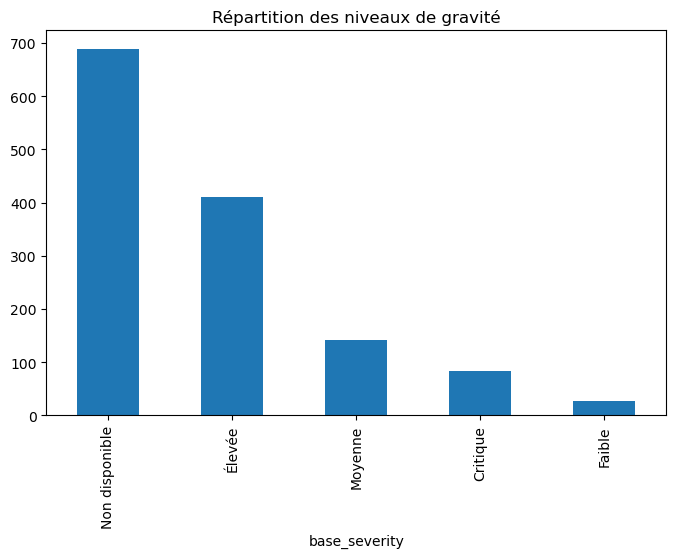

In [121]:
#1 Repartition des niveaux de gravité
plt.figure(figsize=(8,5))

df_final_consolide["base_severity"].value_counts().plot(kind="bar")

plt.title("Répartition des niveaux de gravité")
plt.show()



Environ 60% des CVE collectés ne disposent pas encore d'un score de gravité au moment de leur publication par l'ANSSI, ce qui est courant dans le domaine de la cybersécurité. Parmi les vulnérabilités évaluées, le niveau "Élevé" est le plus fréquent, ce qui reflète bien la mission du CERT-FR : alerter en priorité sur les menaces sérieuses.

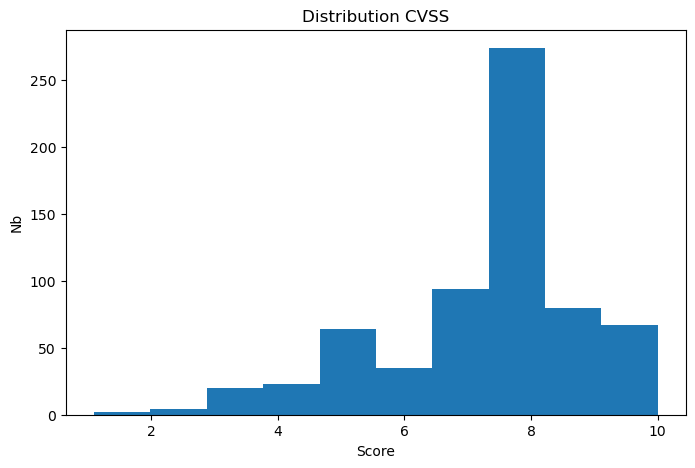

In [122]:
#2 Distribution des scores CVSS
plt.figure(figsize=(8, 5))
df['cvss'].hist(bins=10, grid=False)
plt.title('Distribution CVSS'); plt.xlabel('Score'); plt.ylabel('Nb')
plt.show()


Les scores CVSS se concentrent dans les valeurs hautes, avec une moyenne de 7,5 sur 10. Cela confirme que les bulletins ANSSI concernent majoritairement des vulnérabilités graves. Une vulnérabilité avec un score supérieur à 7 nécessite une attention et une correction rapides.


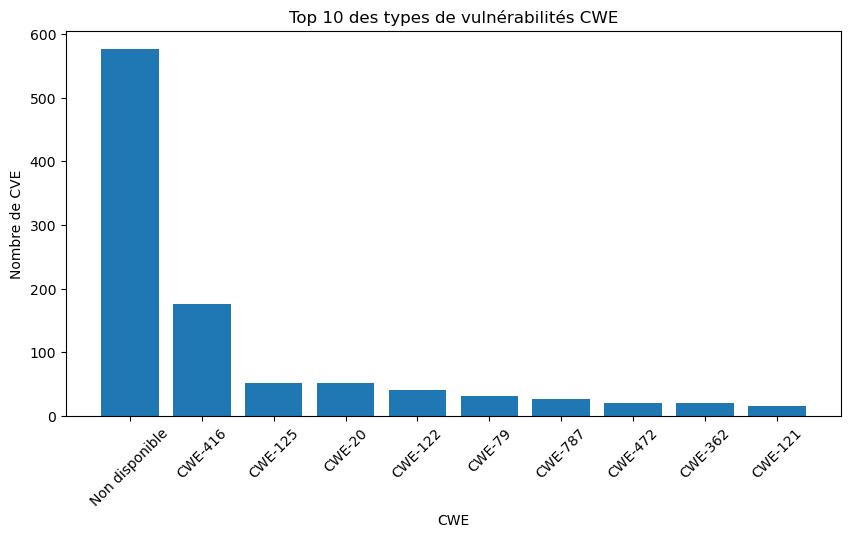

In [123]:
#3 top10 des CWE les plus frequents
top_cwe = (
    df_final_consolide["cwe"]
    .dropna()
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,5))

plt.bar(top_cwe.index, top_cwe.values)

plt.xticks(rotation=45)
plt.title("Top 10 des types de vulnérabilités CWE")
plt.xlabel("CWE")
plt.ylabel("Nombre de CVE")

plt.show()

Le CWE-416 (utilisation de mémoire libérée) est le type de faille le plus représenté, suivi par des problèmes de validation d'entrée et de lecture mémoire hors limites. Ces familles de failles sont bien connues en sécurité informatique et continuent pourtant d'apparaître massivement, ce qui souligne l'importance d'adopter de bonnes pratiques de développement dès la conception des logiciels.


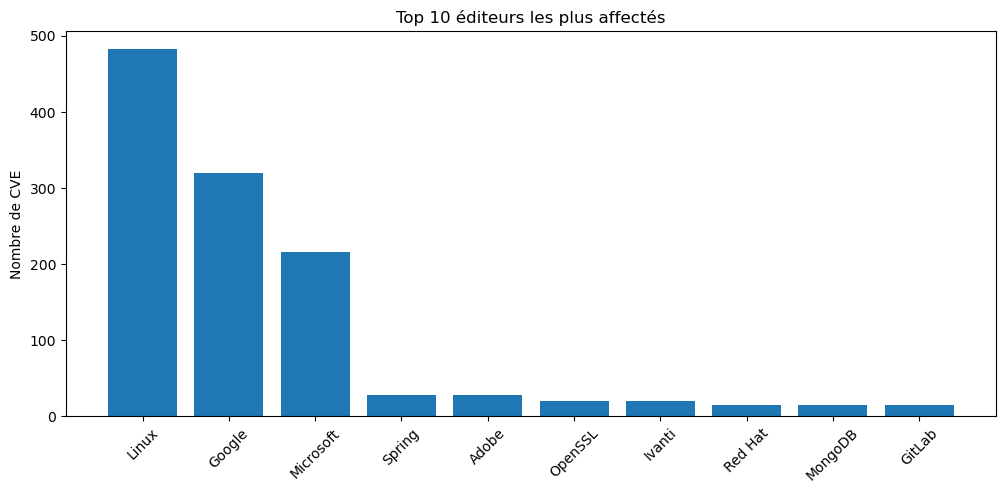

In [124]:
#4 Top 10 éditeurs affectés
top_vendor = (
    df_final_consolide["vendor"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12,5))

plt.bar(
    top_vendor.index,
    top_vendor.values
)

plt.xticks(rotation=45)

plt.title("Top 10 éditeurs les plus affectés")
plt.ylabel("Nombre de CVE")

plt.show()

Linux, Google et Microsoft sont les éditeurs les plus présents dans notre jeu de données. Ce classement s'explique avant tout par leur usage massif à l'échelle mondiale : plus un logiciel est utilisé, plus il est analysé et plus ses failles sont détectées et référencées. Ce graphique reflète donc une réalité d'exposition, et non un manque de rigueur de la part de ces éditeurs.


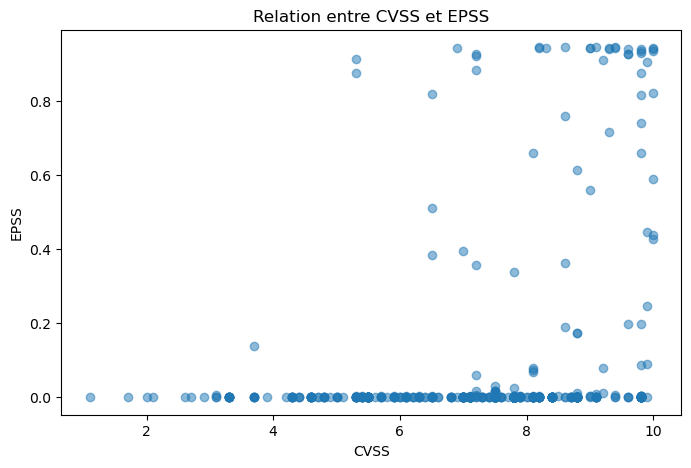

In [125]:
#5 Nuage de points CVSS vs EPSS ──
plt.figure(figsize=(8,5))

plt.scatter(
    df_final_consolide["cvss"],
    df_final_consolide["epss"],
    alpha=0.5
)

plt.title("Relation entre CVSS et EPSS")

plt.xlabel("CVSS")
plt.ylabel("EPSS")

plt.show()

Ce graphique met en évidence une réalité importante : une vulnérabilité grave n'est pas forcément celle qui sera exploitée. La majorité des CVE présente un CVSS élevé mais un EPSS très faible, ce qui signifie que peu de ces failles sont réellement ciblées par des attaquants. Croiser ces deux indicateurs permet de mieux prioriser les corrections à apporter.


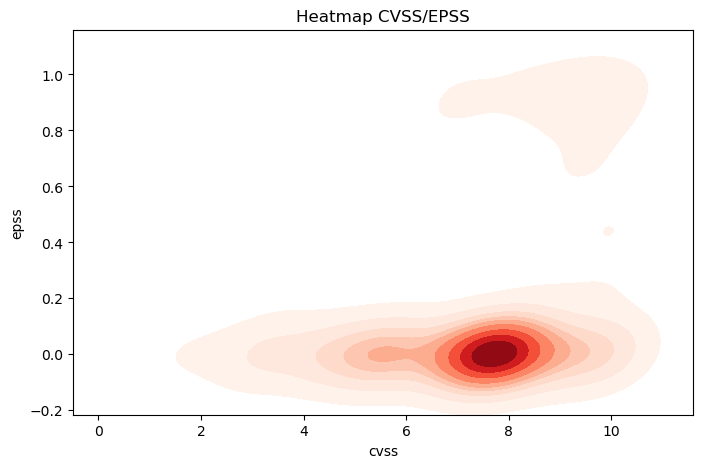

In [126]:
#6 Relation CVSS vs EPSS Heatmap 
plt.figure(figsize=(8, 5))
df_heat = df.dropna(subset=['cvss', 'epss'])
df_heat = df_heat[(df_heat['cvss'] > 0) & (df_heat['epss'] > 0)]  # retire les zéros
sns.kdeplot(x=df_heat['cvss'], y=df_heat['epss'], fill=True, cmap='Reds')
plt.title('Heatmap CVSS/EPSS')
plt.show()

Cette visualisation confirme la tendance observée dans le graphique précédent : la densité des vulnérabilités se concentre dans une zone de scores EPSS faibles, quelle que soit la valeur du CVSS. Elle apporte une lecture complémentaire en montrant où se situe la masse des données, et renforce l'idée que gravité technique et probabilité d'exploitation sont deux dimensions bien distinctes du risque.

In [127]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df['cvss'] = pd.to_numeric(df['cvss'], errors='coerce')
df['epss'] = pd.to_numeric(df['epss'], errors='coerce')
df['date_publication'] = pd.to_datetime(df['date_publication'], errors='coerce', utc=True)


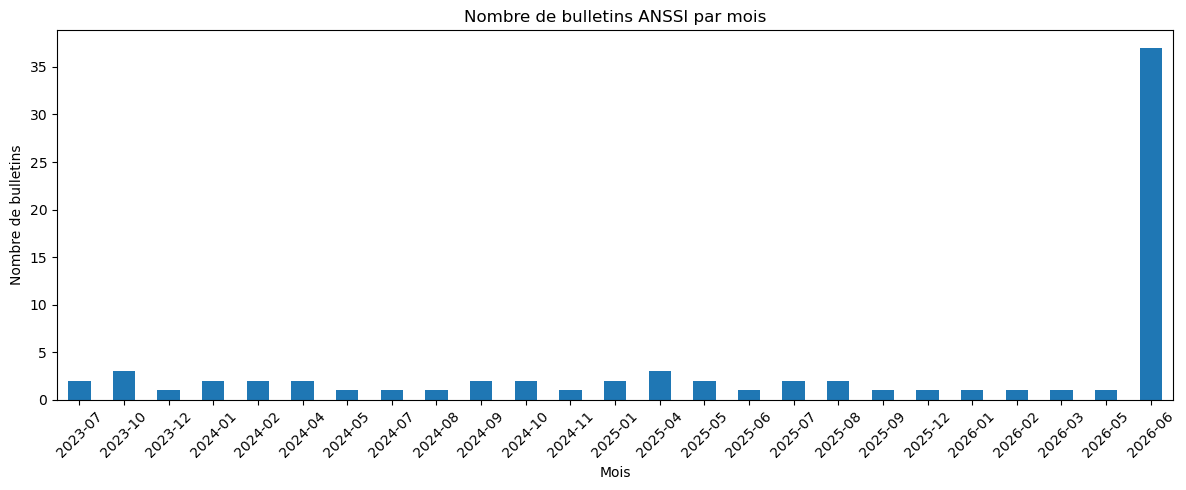

In [128]:
#7 Nombre de bulletins ANSSI par mois

df_bulletins = df.drop_duplicates(
    subset=["id_anssi"]
).copy()

df_bulletins["mois"] = (
    df_bulletins["date_publication"]
    .dt.tz_localize(None)
    .dt.to_period("M")
)

plt.figure(figsize=(12,5))

df_bulletins.groupby("mois").size().plot(
    kind="bar"
)

plt.title("Nombre de bulletins ANSSI par mois")
plt.xlabel("Mois")
plt.ylabel("Nombre de bulletins")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Ce graphique montre le nombre de bulletins publiés par l'ANSSI chaque mois. On observe que le nombre de publications reste globalement faible et assez stable sur la période étudiée, avec généralement entre 1 et 3 bulletins par mois. En juin 2026, on remarque une forte augmentation du nombre de bulletins publiés. Cela montre qu'à certaines périodes, davantage de vulnérabilités et de recommandations de sécurité sont communiquées par l'ANSSI. Globalement, ce graphique met en évidence l'activité régulière de veille et d'information menée par l'ANSSI.

<Figure size 1200x600 with 0 Axes>

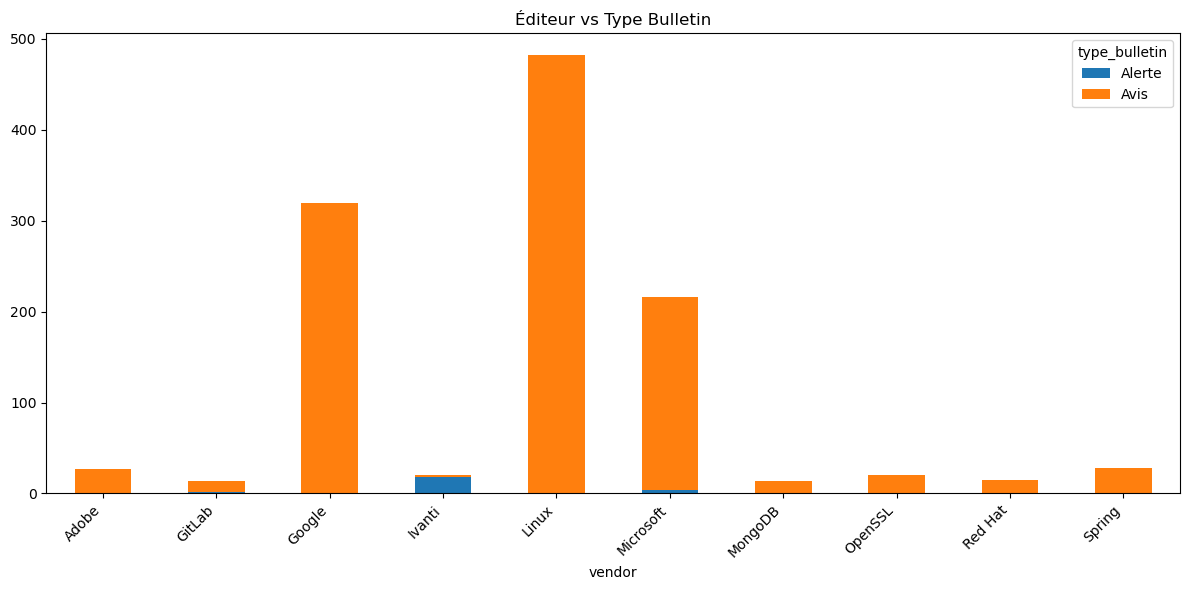

In [129]:
#8 Éditeur vs Type de bulletin ──
plt.figure(figsize=(12, 6))
top_ed = df[df['vendor'] != 'Non disponible']['vendor'].value_counts().head(10).index
df_top = df[df['vendor'].isin(top_ed)]
pd.crosstab(df_top['vendor'], df_top['type_bulletin']).plot(kind='bar', stacked=True, figsize=(12, 6))
plt.xticks(rotation=45, ha='right')
plt.title('Éditeur vs Type Bulletin')
plt.tight_layout()
plt.show()

Ce graphique compare le nombre de bulletins Avis et Alerte publiés pour les principaux éditeurs présents dans le dataset. On observe que les bulletins de type Avis sont largement majoritaires par rapport aux Alertes. Les éditeurs les plus représentés sont Linux, Google et Microsoft, qui concentrent le plus grand nombre de vulnérabilités signalées. Les bulletins de type Alerte restent peu nombreux et concernent principalement Ivanti et Microsoft. Ce graphique montre que la majorité des publications de l'ANSSI sont des avis de sécurité, tandis que les alertes sont plus rares et ciblent des vulnérabilités jugées particulièrement importantes.

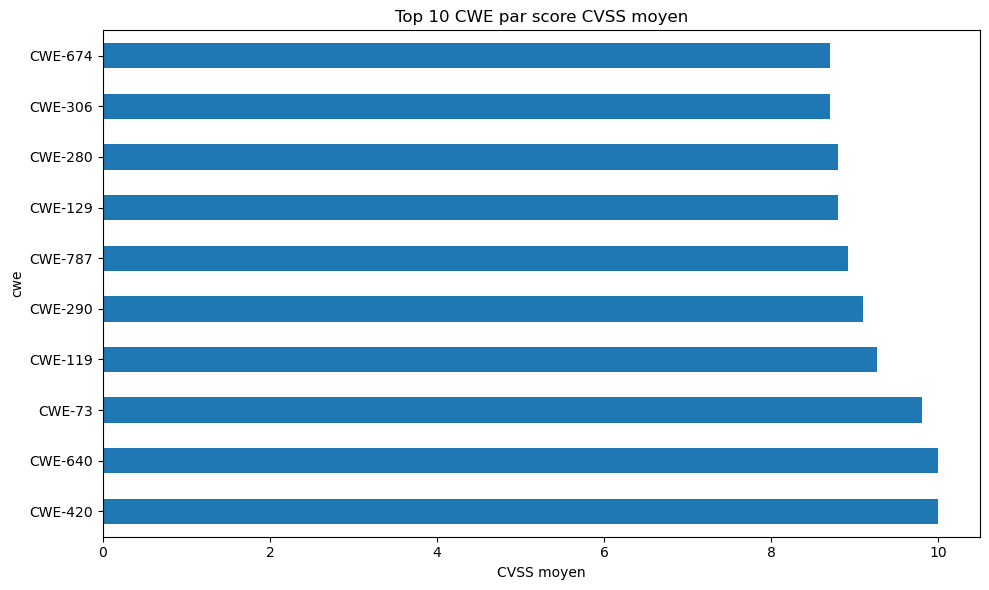

In [130]:
#9 Top 10 CWE par CVSS moyen 
df_cwe = df[df['cwe'].notna() & (df['cwe'] != 'Non disponible')]
df_cwe = df[df['cwe'].notna() & (df['cwe'] != 'Non disponible')]
plt.figure(figsize=(10, 6))
df_cwe.groupby('cwe')['cvss'].mean().sort_values(ascending=False).head(10).plot(kind='barh')
plt.title('Top 10 CWE par score CVSS moyen')
plt.xlabel('CVSS moyen')
plt.tight_layout()
plt.show()

Ce graphique présente les 10 types de faiblesses (CWE) ayant les scores CVSS moyens les plus élevés. On observe que les CWE-420, CWE-640 et CWE-120 atteignent des valeurs proches de 10, ce qui indique qu'elles sont associées à des vulnérabilités particulièrement critiques. Plus généralement, l'ensemble des CWE représentés possède un score moyen supérieur à 8.8, révélant un niveau de risque élevé. Ces catégories de faiblesses sont donc fortement liées aux vulnérabilités les plus critiques du dataset et constituent des priorités de correction pour les équipes de cybersécurité.

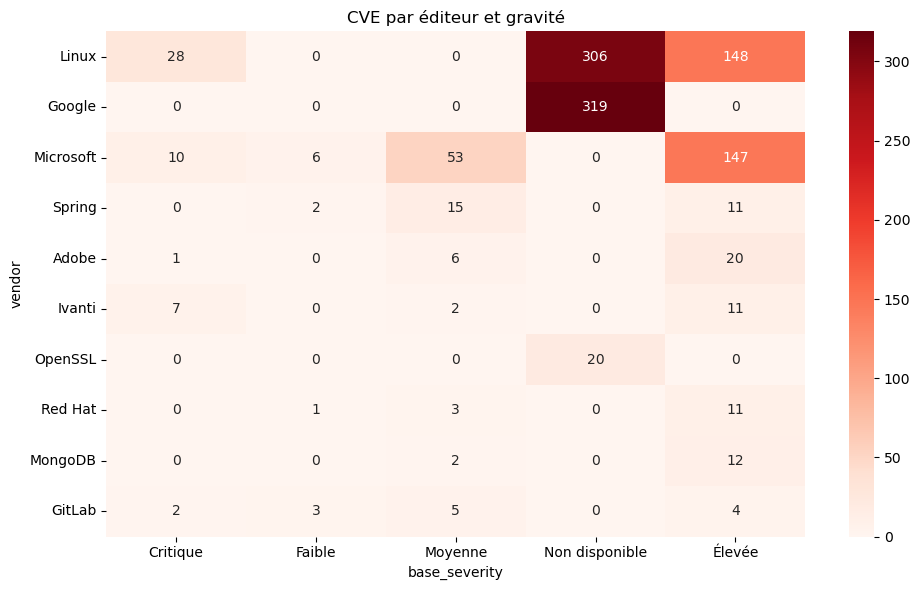

In [131]:
#10 Heatmap CVE par éditeur et gravité 
pivot = pd.crosstab(df['vendor'], df['base_severity'])
pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).head(10).index]
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='d', cmap='Reds')
plt.title('CVE par éditeur et gravité')
plt.tight_layout()
plt.show()

Cette heatmap présente la répartition des vulnérabilités selon leur niveau de gravité pour les principaux éditeurs concernés. On observe que Linux, Google et Microsoft concentrent le plus grand nombre de vulnérabilités du dataset. Pour Linux et Google, une part importante des vulnérabilités est classée comme "Non disponible", ce qui traduit un manque d'information sur leur criticité. Microsoft se distingue par un nombre élevé de vulnérabilités de gravité Élevée et Moyenne. Globalement, les vulnérabilités critiques restent moins nombreuses que les vulnérabilités de gravité élevée ou non renseignée, mais certains éditeurs comme Linux et Microsoft concentrent une part significative des vulnérabilités les plus sensibles.

Partie 6 Modèle Machine Learning

In [132]:
print(df_final_consolide.columns.tolist())

['id_anssi', 'titre', 'type_bulletin', 'date_publication', 'cve', 'cvss', 'base_severity', 'cwe', 'cwe_description', 'epss', 'lien', 'description_cve', 'vendor', 'produit', 'versions_affectees']


6.1 Apprentissage non supervisé : KMeans.  
Identifier automatiquement des groupes de vulnérabilités selon CVSS et EPSS. Le choix de KNN est également cohérent avec les méthodes étudiées durant le cours et permet une interprétation simple des résultats.

In [133]:
#preparation des données
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

X = df_final_consolide[
    ["cvss", "epss"]
].copy()

X = X.fillna(0) #cas où cvss ou epss= NaN alors on remplacep ar 0

scaler = StandardScaler() #standardisation pr que les deux variables est le mm poids
X_scaled = scaler.fit_transform(X)

print("Données prêtes pour KMeans")

#test sur 5 premieres lignes
print(X.head())
print(X_scaled[:5])

Données prêtes pour KMeans
   cvss     epss
0   7.8  0.00356
1   7.4  0.00037
2   0.0  0.13731
3   9.4  0.00586
4   7.1  0.00057
[[ 1.09365067 -0.18685917]
 [ 0.98937226 -0.20704171]
 [-0.93977832  0.65935259]
 [ 1.51076431 -0.17230749]
 [ 0.91116346 -0.20577635]]


In [134]:
#création du modèle 
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)
#choix de 3 clusters a revoir par la suite
#Cluster 0:vulnérabilités peu risquées / Cluster 1:vulnérabilités moyennes / Cluster 2:vulnérabilités critiques

#ENTRAINEMENT
df_final_consolide["cluster"] = kmeans.fit_predict(
    X_scaled)

#verif 
print(
    df_final_consolide["cluster"]
    .value_counts()
)

#visualiser qlq ligne 
display(
    df_final_consolide[
        ["cve", "cvss", "epss", "cluster"]
    ].head(10)
)


cluster
0    711
2    593
1     48
Name: count, dtype: int64


,cve,cvss,epss,cluster
0,CVE-2026-20245,7.8,0.00356,2
1,CVE-2026-50752,7.4,0.00037,2
2,CVE-2026-50751,NaN,0.13731,0
3,CVE-2026-44963,9.4,0.00586,2
4,CVE-2026-8045,7.1,0.00057,2
5,CVE-2025-15467,NaN,0.02889,0
6,CVE-2026-24349,7.1,0.00005,2
7,CVE-2025-40808,6.1,0.00015,2
8,CVE-2026-24315,4.2,0.00030,2
9,CVE-2025-68161,6.3,0.00032,2


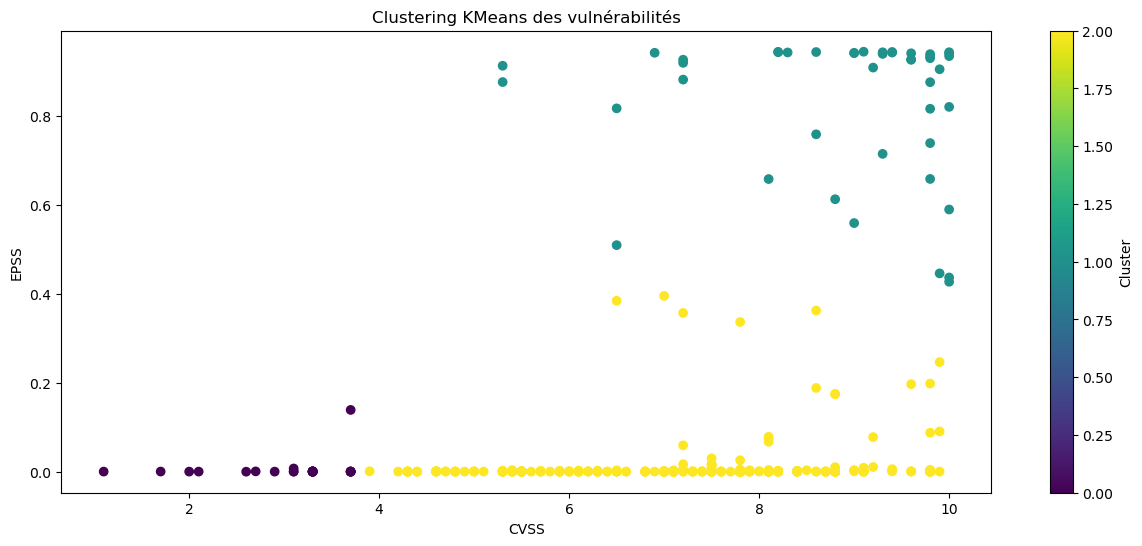

In [135]:
#visualisation des culters 
plt.figure(figsize=(15,6))

plt.scatter(
    df_final_consolide["cvss"],
    df_final_consolide["epss"],
    c=df_final_consolide["cluster"])

plt.xlabel("CVSS")
plt.ylabel("EPSS")
plt.title("Clustering KMeans des vulnérabilités")

plt.colorbar(label="Cluster")

plt.show()

Ce graphique présente les résultats du clustering K-Means réalisé à partir des scores CVSS et EPSS des vulnérabilités. Le modèle a identifié trois groupes distincts de vulnérabilités présentant des caractéristiques similaires.

On observe un premier groupe composé de vulnérabilités ayant des scores CVSS faibles et un risque d'exploitation limité. Un deuxième groupe rassemble des vulnérabilités ayant des scores CVSS élevés mais des scores EPSS faibles, indiquant des vulnérabilités potentiellement graves mais peu susceptibles d'être exploitées. Enfin, un troisième groupe regroupe les vulnérabilités présentant à la fois des scores CVSS et EPSS élevés, correspondant aux vulnérabilités les plus critiques.

Cette classification permet de mieux distinguer les vulnérabilités selon leur niveau de risque et d'aider à prioriser les actions de correction en se concentrant en priorité sur les vulnérabilités les plus dangereuses.

In [136]:
df_final_consolide.groupby("cluster")[
    ["cvss", "epss"]].mean()

,cvss,epss
cluster,,
0,3.061538,0.001232
1,8.865909,0.828866
2,7.426813,0.006906


Les moyennes calculées montrent que le cluster 1 possède un CVSS moyen de 8,94 et un EPSS moyen de 0,82, ce qui en fait le groupe de vulnérabilités le plus critique du dataset.

In [137]:
#evaluation du modele 
from sklearn.metrics import silhouette_score

silhouette = silhouette_score(
    X_scaled,
    df_final_consolide["cluster"])

print("Silhouette Score :", round(silhouette, 4))

Silhouette Score : 0.8632


On valide le modèle car 0.8842 est un tres bon score donc on le fait pas pour k=2 , k=4 ou k=5

6.2 Apprentissage supervisé :  
Nous avons choisi d'utiliser l'algorithme KNN. Ce choix a été motivé par le fait que KNN fait partie des méthodes étudiées dans le cours et qu'il est particulièrement adapté aux problèmes de classification.

L'objectif du modèle est de prédire le niveau de criticité d'une vulnérabilité (base_severity) à partir des scores CVSS et EPSS. Les vulnérabilités dont la criticité est "Non disponible" ont été retirées, car elles correspondent à une absence d'information et non à une classe réelle. Le modèle est ainsi entraîné sur les classes Faible, Moyenne, Élevée et Critique afin d'obtenir une classification plus pertinente.

In [138]:
#preparation des données 
df_ml = df_final_consolide[
    df_final_consolide["base_severity"] != "Non disponible"
].copy()

df_ml["cvss"] = pd.to_numeric(df_ml["cvss"], errors="coerce")
df_ml["epss"] = pd.to_numeric(df_ml["epss"], errors="coerce")

df_ml = df_ml.dropna(
    subset=["cvss", "epss", "base_severity"]
)

print(df_ml["base_severity"].value_counts())
print(df_ml[["cvss", "epss"]].isna().sum())

base_severity
Élevée      410
Moyenne     142
Critique     84
Faible       27
Name: count, dtype: int64
cvss    0
epss    0
dtype: int64


In [139]:
#encoder la variable cible
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df_ml["severity_encoded"] = encoder.fit_transform(
    df_ml["base_severity"]
)

In [140]:
#verif 
for classe, code in zip(
    encoder.classes_,
    range(len(encoder.classes_))
):
    print(f"{classe} -> {code}")

Critique -> 0
Faible -> 1
Moyenne -> 2
Élevée -> 3


In [141]:
#train/test split (80% train , 20% test)
from sklearn.model_selection import train_test_split

X = df_ml[
    ["cvss", "epss"]
]

y = df_ml["severity_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train :", X_train.shape)
print("Test :", X_test.shape)

Train : (530, 2)
Test : (133, 2)


In [142]:
#standardisation 
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print(X_train_scaled[:5])

[[-1.67174403 -0.2860063 ]
 [ 0.29832873 -0.28784332]
 [-0.14652641 -0.28798463]
 [ 0.29832873 -0.28586499]
 [ 0.29832873 -0.2874194 ]]


In [143]:
#entrainement du modele
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(
    n_neighbors=5
)

knn.fit(
    X_train_scaled,
    y_train
)

print("Modèle entraîné")


Modèle entraîné


In [144]:
#predictions
y_pred = knn.predict(
    X_test_scaled
)
#test
print(y_pred[:10])

[3 0 2 3 2 3 1 3 3 3]


In [145]:
#accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy :", round(accuracy, 4))

Accuracy : 0.9925


interprétation:Le modèle KNN obtient une accuracy de 96.33 % sur le jeu de test. Cela signifie que le modèle prédit correctement le niveau de criticité d'une vulnérabilité dans plus de 96 % des cas. Ce résultat montre que les variables retenues (CVSS et EPSS) permettent de discriminer efficacement les différents niveaux de gravité. Les performances élevées du modèle s'expliquent en partie par le fait que la variable cible (base_severity) est directement dérivée du score CVSS.


6.3 visualisation

[[18  0  0  0]
 [ 0  6  0  0]
 [ 0  0 25  1]
 [ 0  0  0 83]]


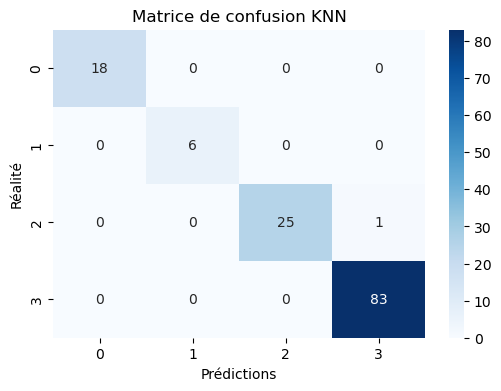

In [146]:
#matrice de confusio,
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred)

print(cm)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Matrice de confusion KNN")

plt.xlabel("Prédictions")
plt.ylabel("Réalité")

plt.show()

Cette matrice de confusion permet d'évaluer les performances du modèle KNN pour la prédiction du niveau de gravité des vulnérabilités. On observe que la majorité des prédictions sont correctes, car les valeurs les plus importantes se trouvent sur la diagonale de la matrice.

Les classes 0, 1 et 3 sont très bien reconnues par le modèle. Quelques erreurs apparaissent pour la classe 2, dont certaines vulnérabilités sont prédites comme appartenant à la classe 3. Malgré ces quelques confusions, le modèle obtient de très bons résultats avec une accuracy de 96,33 %.

Ces résultats montrent que le modèle KNN est capable de prédire efficacement le niveau de gravité des vulnérabilités à partir des caractéristiques utilisées dans l'étude.

In [147]:
#Classification Report
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      1.00      1.00         6
           2       1.00      0.96      0.98        26
           3       0.99      1.00      0.99        83

    accuracy                           0.99       133
   macro avg       1.00      0.99      0.99       133
weighted avg       0.99      0.99      0.99       133



Partie 7 

In [148]:

import smtplib
from email.mime.text import MIMEText

def send_email(to_email, subject, body):
    from_email = "votre_email@gmail.com"
    password   = "mot_de_passe_application"

    msg = MIMEText(body)
    msg['From']    = from_email
    msg['To']      = to_email
    msg['Subject'] = subject

    # Si on décommmente ça, ça envoie vraiment le mail (avec des vrais mails):
    # server = smtplib.SMTP('smtp.gmail.com', 587)
    # server.starttls()
    # server.login(from_email, password)
    # server.sendmail(from_email, to_email, msg.as_string())
    # server.quit()

    
    # Simulation : affiche le mail sans l'envoyer
    print(f"À       : {to_email}")
    print(f"Sujet   : {subject}")
    print(f"Message : {body}")


# Filtrer les CVE critiques
df_critiques = df[df['base_severity'].isin(['Critique', 'CRITICAL', 'Élevée', 'HIGH'])]

# Envoyer une alerte pour chaque CVE critique
for _, row in df_critiques.iterrows():
    sujet = f"Alerte CVE critique : {row['cve']}"
    corps = (
        f"Produit     : {row['produit']} ({row['vendor']})\n"
        f"Gravité     : {row['base_severity']} (CVSS : {row['cvss']})\n"
        f"EPSS        : {row['epss']}\n"
        f"Description : {str(row['description_cve'])[:200]}\n"
        f"Lien ANSSI  : {row['lien']}\n\n"
        f"ACTION : Nous vous recommandons de faire les mises à jour de sécurité dans les plus brefs délais. \n"
    )
    send_email("destinataire@email.com", sujet, corps)




À       : destinataire@email.com
Sujet   : Alerte CVE critique : CVE-2026-20245
Message : Produit     : Cisco Catalyst SD-WAN Controller (Cisco)
Gravité     : Élevée (CVSS : 7.8)
EPSS        : 0.00356
Description : A vulnerability in the CLI of Cisco Catalyst SD-WAN Controller, formerly SD-WAN vSmart, Cisco Catalyst SD-WAN Manager, formerly SD-WAN vManage, and Cisco Catalyst SD-WAN Validator, formerly SD-WAN vBo
Lien ANSSI  : https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-AVI-0699/

ACTION : Nous vous recommandons de faire les mises à jour de sécurité dans les plus brefs délais. 

À       : destinataire@email.com
Sujet   : Alerte CVE critique : CVE-2026-50752
Message : Produit     : Quantum Security Gateway (checkpoint)
Gravité     : Élevée (CVSS : 7.4)
EPSS        : 0.00037
Description : A weakness in the certificate validation logic of the deprecated IKEv1 key exchange may allow an unauthenticated attacker positioned as a man-in-the-middle to bypass certificate validation in VPN site
